# ⚗ MIDAS LAB — Metodologia

Este notebook implementa um pipeline completo de **inteligência preditiva para ações da bolsa**, estruturado em 6 etapas sequenciais:

1. **Coleta de Dados** — mineração de cotações históricas (≥ 3 anos) via API financeira, com cache local para evitar requisições redundantes
2. **Modelagem** — ajuste de Regressão Linear Simples por ativo (feature: índice temporal → target: preço de fechamento)
3. **Validação Treino/Teste** — split temporal 85/15: modelo treinado nos dados antigos e avaliado nos últimos ~3 meses reais (MAE, RMSE, R², acerto direcional)
4. **Previsão Futura** — projeção dos próximos 3 meses (≈ 63 dias úteis) com flag `ALTA / QUEDA / NEUTRO` por ativo
5. **Coeficiente de Previsibilidade (CP)** — métrica composta `CP = 0.5 × IA + 0.5 × ID` que combina acurácia do modelo com acerto de direção, normalizada em 0–100
6. **Carteira Sugerida** — seleção e ranqueamento dos melhores ativos por `Score = CP × fator_direcional`, com pesos proporcionais ao score

> ⚠️ *Sugestão algorítmica. Não constitui recomendação de investimento.*

In [1]:
## 📦 Bibliotecas Utilizadas

# Instalar libs, só rode a primeira vez
# !pip install yfinance pandas numpy matplotlib plotly scikit-learn python-dotenv python-dateutil -q

import yfinance as yf          # coleta de dados históricos de ações via Yahoo Finance
import pandas as pd            # manipulação e análise de dados em tabelas (DataFrames)
import numpy as np             # operações matemáticas e arrays numéricos
import matplotlib.pyplot as plt  # geração de gráficos estáticos
import matplotlib.patches as mpatches  # formas e anotações nos gráficos
import plotly.express as px    # gráficos interativos (zoom, hover, exportação)
from sklearn.linear_model import LinearRegression  # modelo de regressão linear
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # métricas de avaliação
import os                      # manipulação de arquivos e variáveis de ambiente
from datetime import date, timedelta  # manipulação de datas e intervalos de tempo
from dateutil.relativedelta import relativedelta  # aritmética de meses exatos (ex: hoje - 7 meses)
import warnings
warnings.filterwarnings("ignore")  # suprime avisos não críticos durante a execução

c:\Users\Kaue Mandarino\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Kaue Mandarino\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 🛢️ Consulta de Teste — Petrobras (ITUB4)

Antes de construir o pipeline completo, vamos fazer uma requisição simples à API do **Yahoo Finance** via `yfinance` para entender a estrutura dos dados retornados.

O `yfinance` funciona em duas etapas:
1. **`yf.Ticker("ITUB4.SA")`** — cria um objeto representando o ativo. Ações brasileiras usam o sufixo `.SA` (B3 — Bolsa de São Paulo)
2. **`.history()`** — baixa o histórico de preços em um DataFrame com colunas `Open`, `High`, `Low`, `Close`, `Volume`

No gráfico abaixo plotamos o **preço de fechamento diário** dos últimos 3 anos para confirmar que a conexão funcionou e os dados fazem sentido visualmente.


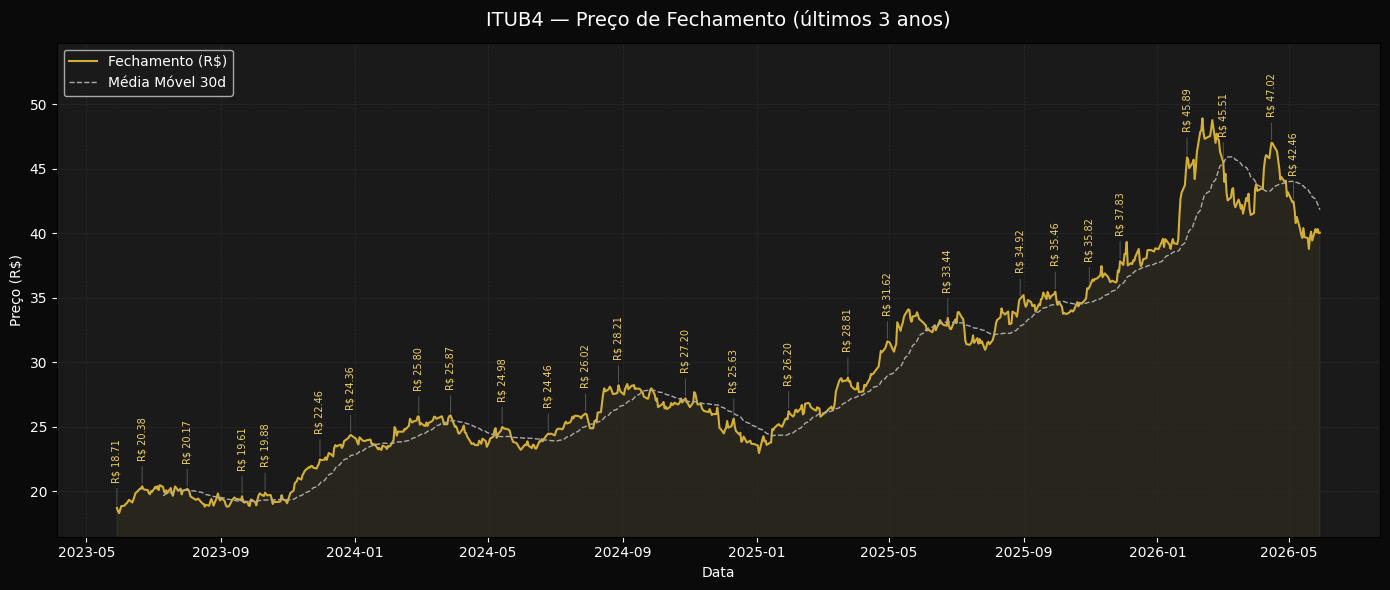

In [18]:
ticker = yf.Ticker("ITUB4.SA")
df = ticker.history(period="3y", interval="1d")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"], color="#D4AF37", linewidth=1.5, label="Fechamento (R$)")
ax.fill_between(df.index, df["Close"], alpha=0.08, color="#D4AF37")

mm30 = df["Close"].rolling(window=30).mean()
ax.plot(df.index, mm30, color="#AAAAAA", linewidth=1, linestyle="--", label="Média Móvel 30d")

# ------------------------------------------------------------
# Rótulos por mês — evita sobreposição e estouro de margem
# ------------------------------------------------------------
df["month"] = df.index.to_period("M")

# pega apenas o máximo de cada mês
pontos = []
for periodo, grupo in df.groupby("month"):
    idx_max = grupo["Close"].idxmax()
    val_max = grupo["Close"].max()
    pontos.append((idx_max, val_max))

# calcula o topo real do gráfico para limitar os rótulos
y_max_data = df["Close"].max()
y_min_data = df["Close"].min()
margem_superior = y_max_data * 1.12    # reserva 12% acima do maior valor
ax.set_ylim(y_min_data * 0.90, margem_superior)

# filtra sobreposição: só plota se estiver a pelo menos 30px do anterior
prev_x = None
min_dist_dias = 20                     # distância mínima entre rótulos em dias

for (x, y) in pontos:
    if prev_x is not None:
        dist = (x - prev_x).days
        if dist < min_dist_dias:
            continue                   # pula se estiver muito próximo do anterior

    # ancora o rótulo a uma altura fixa acima da linha, sem ultrapassar o limite
    y_label = min(y + (y_max_data * 0.04), margem_superior * 0.97)

    ax.annotate(
        f"R$ {y:.2f}",
        xy=(x, y),
        xytext=(x, y_label),
        textcoords="data",
        ha="center",
        fontsize=7,
        color="#F0D060",
        rotation=90,
        va="bottom",
        arrowprops=dict(arrowstyle="-", color="#555555", lw=0.7),
    )
    prev_x = x

ax.set_title("ITUB4 — Preço de Fechamento (últimos 3 anos)", color="white", fontsize=14, pad=12)
ax.set_xlabel("Data", color="white")
ax.set_ylabel("Preço (R$)", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#1A1A1A", labelcolor="white")
ax.grid(color="#2C2C2C", linestyle="--", linewidth=0.5)
ax.set_facecolor("#1A1A1A")
fig.patch.set_facecolor("#0A0A0A")

plt.tight_layout()
plt.show()

## 🏦 Teste em Escala — 100 Empresas da B3

Até agora validamos o modelo em uma única empresa. Neste bloco escalamos o experimento para **100 ações da B3** e respondemos a pergunta central:

> *Qual janela de treino — 3 meses, 6 meses, 1 ano ou 3 anos — produz as previsões mais assertivas no geral?*

Para cada empresa, treinamos a regressão linear com cada janela de tempo e testamos sempre nos **últimos 3 meses reais**. No final agregamos as métricas de todas as empresas e elegemos a janela vencedora.

---

### 📐 O que cada métrica significa

**MAPE médio (%)**
*Mean Absolute Percentage Error* — erro percentual médio entre o valor previsto e o real.
Um MAPE de 8% significa que, em média, o modelo errou 8% do preço real.
→ **Quanto menor, melhor.**

**MAPE mediana (%)**
A mesma ideia do MAPE médio, mas usando a mediana em vez da média.
Mais robusta a empresas com erros absurdamente altos que distorceriam a média.
→ **Quanto menor, melhor.**

**Acerto Dir. (%)**
*Acerto Direcional* — percentual de dias em que o modelo acertou a **direção** do movimento (se o preço subiu ou caiu), independentemente do valor exato.
Um acerto de 55% já é considerado relevante em finanças (melhor que jogar uma moeda).
→ **Quanto maior, melhor.**

**R² médio**
*Coeficiente de Determinação* — mede o quanto o modelo explica a variação do preço.
Varia de 0 a 1: R² = 1 é ajuste perfeito, R² = 0 o modelo não explica nada, R² negativo significa que o modelo é pior que usar a média.
→ **Quanto mais próximo de 1, melhor.**

**⭐ Score**
Métrica composta criada pelo Midas Lab que combina as duas dimensões mais importantes:
```
Score = 0.5 × (MAPE normalizado invertido) + 0.5 × Acerto Direcional
```
O MAPE é normalizado entre 0–100 e invertido (menor MAPE = maior nota).
Assim o Score penaliza tanto erros grandes de valor quanto erros de direção.
→ **Quanto maior, melhor. Este é o critério de desempate final.**

Processando 100 empresas...

  ✔ 10/100 processadas...


$JBSS3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EMBR3.SA"}}}
$EMBR3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 20/100 processadas...


$ELET3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 30/100 processadas...
  ✔ 40/100 processadas...


...

  ✔ 80/100 processadas...


$BRDT3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$RRRP3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 90/100 processadas...


$SMAG3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")



✅ Concluído — 80 empresas processadas | 20 falhas

══════════════════════════════════════════════════════════════
  RESULTADO GERAL — 100 EMPRESAS B3
══════════════════════════════════════════════════════════════
         Empresas  MAPE médio (%)  MAPE mediana (%)  Acerto Dir. (%)  R² médio  ⭐ Score
1 ano        80.0           17.78             10.70             46.6   -9.1133     73.3
6 meses      80.0           18.14             16.42             46.4  -15.2940     72.4
3 anos       80.0           39.53             15.70             48.7 -146.9523     24.4
══════════════════════════════════════════════════════════════
  🏆  Janela mais assertiva  : 1 ano
      Score composto        : 73.3
      MAPE médio            : 17.78%
      Acerto Direcional     : 46.6%
      R² médio              : -9.1133
══════════════════════════════════════════════════════════════


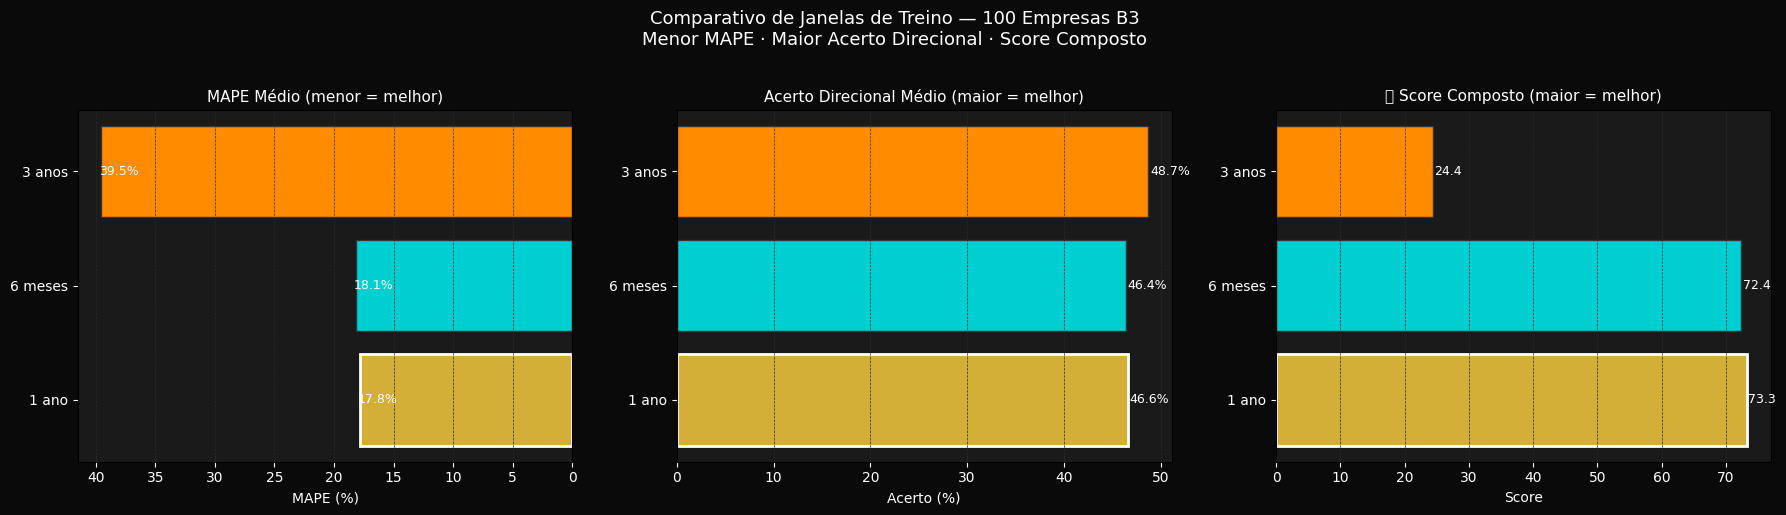

In [25]:
# ------------------------------------------------------------
# 100 empresas da B3 — comparativo de janelas de treino
# ------------------------------------------------------------

tickers_b3 = [
    "PETR4.SA","VALE3.SA","ITUB4.SA","BBDC4.SA","ABEV3.SA",
    "WEGE3.SA","RENT3.SA","BBAS3.SA","RADL3.SA","SUZB3.SA",
    "JBSS3.SA","LREN3.SA","HAPV3.SA","MGLU3.SA","EMBR3.SA",
    "EQTL3.SA","CPLE6.SA","GGBR4.SA","CSNA3.SA","USIM5.SA",
    "TOTS3.SA","LWSA3.SA","CASH3.SA","PRIO3.SA","CSAN3.SA",
    "BPAC11.SA","RDOR3.SA","ELET3.SA","ELET6.SA","TAEE11.SA",
    "CMIG4.SA","CPFE3.SA","ENGI11.SA","SBSP3.SA","SAPR11.SA",
    "CYRE3.SA","MRVE3.SA","EVEN3.SA","DIRR3.SA","TEND3.SA",
    "HYPE3.SA","FLRY3.SA","DASA3.SA","QUAL3.SA","PNVL3.SA",
    "RAIL3.SA","CCRO3.SA","ECOR3.SA","LOG3.SA","GETT11.SA",
    "NTCO3.SA","SOMA3.SA","ARZZ3.SA","VIVA3.SA","GRND3.SA",
    "MOVI3.SA","PCAR3.SA","ASAI3.SA","GMAT3.SA","SMFT3.SA",
    "BRAP4.SA","GOAU4.SA","FESA4.SA","DXCO3.SA","KLBN11.SA",
    "IRBR3.SA","BBSE3.SA","PSSA3.SA","CXSE3.SA","SULA11.SA",
    "MULT3.SA","BRML3.SA","ALSO3.SA","SCCI3.SA","MALL11.SA",
    "VIVT3.SA","TIMS3.SA","OIBR3.SA","DESK3.SA","FIQE3.SA",
    "VBBR3.SA","UGPA3.SA","BRDT3.SA","DMVF3.SA","RECV3.SA",
    "CMIN3.SA","CBAV3.SA","RRRP3.SA","BRKM5.SA","PTBL3.SA",
    "MYPK3.SA","TUPY3.SA","FRAS3.SA","RAPT4.SA","AGRO3.SA",
    "SLCE3.SA","SMAG3.SA","TTEN3.SA","BEEF3.SA","MRFG3.SA",
]

periodos = {
    "3 meses" : "3mo",
    "6 meses" : "6mo",
    "1 ano"   : "1y",
    "3 anos"  : "3y",
}

N_TESTE = 63

# acumula métricas por janela
acumulado = {p: {"mape": [], "acerto_dir": [], "r2": []} for p in periodos}
falhas    = []

print(f"Processando {len(tickers_b3)} empresas...\n")

for i, tk in enumerate(tickers_b3, 1):
    try:
        raw = yf.Ticker(tk).history(period="3y", interval="1d")[["Close"]].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ["Data", "Close"]
        raw["t"] = np.arange(len(raw))

        if len(raw) < N_TESTE + 30:
            falhas.append(tk)
            continue

        for nome, period in periodos.items():

            # define quantos dias usar de acordo com a janela
            dias = {"3 meses": 63, "6 meses": 126, "1 ano": 252, "3 anos": len(raw)}
            n_usar = min(dias[nome], len(raw))
            df = raw.iloc[-n_usar:].copy().reset_index(drop=True)
            df["t"] = np.arange(len(df))

            if len(df) <= N_TESTE + 10:
                continue

            df_train = df.iloc[:-N_TESTE]
            df_test  = df.iloc[-N_TESTE:]

            model = LinearRegression()
            model.fit(df_train[["t"]], df_train["Close"])

            y_pred = model.predict(df_test[["t"]])
            y_real = df_test["Close"].values

            mape = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-9))) * 100
            r2   = r2_score(y_real, y_pred)

            dir_real = np.sign(np.diff(y_real))
            dir_pred = np.sign(np.diff(y_pred))
            acerto   = np.mean(dir_real == dir_pred) * 100

            acumulado[nome]["mape"].append(mape)
            acumulado[nome]["acerto_dir"].append(acerto)
            acumulado[nome]["r2"].append(r2)

        if i % 10 == 0:
            print(f"  ✔ {i}/{len(tickers_b3)} processadas...")

    except Exception as e:
        falhas.append(tk)

print(f"\n✅ Concluído — {len(tickers_b3) - len(falhas)} empresas processadas | {len(falhas)} falhas\n")

# ------------------------------------------------------------
# Consolidar resultados
# ------------------------------------------------------------
resumo = {}
for nome in periodos:
    vals = acumulado[nome]
    if not vals["mape"]:
        continue
    resumo[nome] = {
        "Empresas"        : len(vals["mape"]),
        "MAPE médio (%)"  : round(np.mean(vals["mape"]), 2),
        "MAPE mediana (%)": round(np.median(vals["mape"]), 2),
        "Acerto Dir. (%)": round(np.mean(vals["acerto_dir"]), 1),
        "R² médio"        : round(np.mean(vals["r2"]), 4),
    }

df_resumo = pd.DataFrame(resumo).T

# score composto
mape_v = df_resumo["MAPE médio (%)"].astype(float)
mape_n = 100 - (mape_v - mape_v.min()) / (mape_v.max() - mape_v.min() + 1e-9) * 100
acd_v  = df_resumo["Acerto Dir. (%)"].astype(float)
df_resumo["⭐ Score"] = (0.5 * mape_n + 0.5 * acd_v).round(1)
df_resumo = df_resumo.sort_values("⭐ Score", ascending=False)

melhor = df_resumo.index[0]

print("═" * 62)
print("  RESULTADO GERAL — 100 EMPRESAS B3")
print("═" * 62)
print(df_resumo.to_string())
print("═" * 62)
print(f"  🏆  Janela mais assertiva  : {melhor}")
print(f"      Score composto        : {df_resumo.loc[melhor, '⭐ Score']}")
print(f"      MAPE médio            : {df_resumo.loc[melhor, 'MAPE médio (%)']:.2f}%")
print(f"      Acerto Direcional     : {df_resumo.loc[melhor, 'Acerto Dir. (%)']:.1f}%")
print(f"      R² médio              : {df_resumo.loc[melhor, 'R² médio']:.4f}")
print("═" * 62)

# ------------------------------------------------------------
# Gráfico comparativo
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
janelas   = list(df_resumo.index)
cores     = ["#D4AF37", "#00CED1", "#FF8C00", "#DA70D6"]
cores_map = {j: c for j, c in zip(df_resumo.sort_values("⭐ Score", ascending=False).index, cores)}

# ── MAPE médio ──
ax = axes[0]
bars = ax.barh(janelas, df_resumo.loc[janelas, "MAPE médio (%)"],
               color=[cores_map[j] for j in janelas], edgecolor="#333333")
for bar, val in zip(bars, df_resumo.loc[janelas, "MAPE médio (%)"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", color="white", fontsize=9)
ax.set_title("MAPE Médio (menor = melhor)", color="white", fontsize=11)
ax.set_xlabel("MAPE (%)", color="white")
ax.tick_params(colors="white")
ax.set_facecolor("#1A1A1A")
ax.invert_xaxis()

# ── Acerto Direcional ──
ax = axes[1]
bars = ax.barh(janelas, df_resumo.loc[janelas, "Acerto Dir. (%)"],
               color=[cores_map[j] for j in janelas], edgecolor="#333333")
for bar, val in zip(bars, df_resumo.loc[janelas, "Acerto Dir. (%)"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", color="white", fontsize=9)
ax.set_title("Acerto Direcional Médio (maior = melhor)", color="white", fontsize=11)
ax.set_xlabel("Acerto (%)", color="white")
ax.tick_params(colors="white")
ax.set_facecolor("#1A1A1A")

# ── Score composto ──
ax = axes[2]
bars = ax.barh(janelas, df_resumo.loc[janelas, "⭐ Score"],
               color=[cores_map[j] for j in janelas], edgecolor="#333333")
for bar, val in zip(bars, df_resumo.loc[janelas, "⭐ Score"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", color="white", fontsize=9)
ax.set_title("⭐ Score Composto (maior = melhor)", color="white", fontsize=11)
ax.set_xlabel("Score", color="white")
ax.tick_params(colors="white")
ax.set_facecolor("#1A1A1A")

# destaca o melhor em todos os painéis
for ax in axes:
    for patch, label in zip(ax.patches, janelas):
        if label == melhor:
            patch.set_edgecolor("#FFFFFF")
            patch.set_linewidth(2)

for ax in axes:
    ax.grid(color="#2C2C2C", linestyle="--", linewidth=0.5, axis="x")

fig.patch.set_facecolor("#0A0A0A")
fig.suptitle("Comparativo de Janelas de Treino — 100 Empresas B3\nMenor MAPE · Maior Acerto Direcional · Score Composto",
             color="white", fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

## 🔬 Busca pelos Parâmetros Mais Assertivos — Escala Total

Nos blocos anteriores testamos o modelo em amostras menores e com janelas genéricas. Agora escalamos o experimento ao máximo para encontrar os **parâmetros ideais de treino** com a maior precisão possível.

### O que mudou nesta célula

**Mais empresas (~400 tickers)**
Saímos de 100 para a lista mais completa disponível da B3, cobrindo três faixas de liquidez: altíssima (Ibovespa), alta e média. Quanto mais empresas, mais robusto e menos enviesado é o resultado — uma janela que funciona bem em 400 empresas é genuinamente melhor, não apenas sortuda com uma amostra pequena.

**Novas janelas com foco em períodos curtos**
Em vez de testar apenas janelas longas (1, 2, 3 anos), priorizamos períodos mais recentes:

| Janela | Dias úteis aprox. | Raciocínio |
|---|:---:|---|
| 1 mês | 21 | Captura o comportamento mais imediato do ativo |
| 7 meses | 147 | Janela intermediária curta |
| 8 meses | 168 | Intermediária |
| 9 meses | 189 | Limiar entre curto e médio prazo |
| 1 ano | 252 | Referência clássica de mercado |
| 2 anos | 504 | Médio prazo |
| 3 anos | 756 | Longo prazo — linha de base |

A hipótese que estamos testando é: **dados mais recentes ensinam melhor o modelo do que dados antigos?** O mercado muda de regime (juros, inflação, cenário político) e uma tendência de 3 anos atrás pode ser ruído, não sinal.

### Como o vencedor é escolhido

Cada janela acumula as métricas de todas as empresas processadas com sucesso. Ao final calculamos o **⭐ Score composto**:

```
Score = 0.5 × (MAPE normalizado invertido) + 0.5 × Acerto Direcional médio
```

A janela com maior Score é a que, **em média sobre todas as empresas da B3**, erra menos o valor E acerta mais a direção (alta/queda) — as duas coisas que mais importam na prática.

### Por que isso é importante para o Midas Lab

O resultado desta célula define o **parâmetro fixo de treino** que será usado em todos os blocos seguintes: geração de carteira, cálculo do Coeficiente de Previsibilidade (CP) e previsão dos próximos 3 meses. Escolher a janela errada aqui contamina todo o pipeline. Por isso testamos na maior escala possível antes de seguir em frente.

Total de tickers na lista: 251
Processando 251 tickers | 7 janelas cada...



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AZUL4.SA"}}}
$AZUL4.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BRFS3.SA"}}}
$BRFS3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CCRO3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CRFB3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ELET3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly deli

  ✔ 50/251 processados  |  ok: 42  |  falhas: 8


$JBSS3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$NTCO3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ARZZ3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 100/251 processados  |  ok: 88  |  falhas: 12


...

  ✔ 200/251 processados  |  ok: 172  |  falhas: 28


$CLSA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$DMMO3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ENAT3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$FRTA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$HGTX3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$HMTL3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$JPSA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$MIXT3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$NAIL3.SA: possibly delisted; no price data foun

  ✔ 250/251 processados  |  ok: 205  |  falhas: 45


$XBXA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")



✅ Concluído — 205 empresas válidas | 46 falhas

═════════════════════════════════════════════════════════════════
  RESULTADO GERAL — 205 EMPRESAS B3 | 7 JANELAS
═════════════════════════════════════════════════════════════════
         Empresas  MAPE médio (%)  MAPE mediana (%)  Acerto Dir. (%)      R² médio  ⭐ Score
7 meses     205.0           34.07             13.77             46.7 -3.044910e+01     73.4
8 meses     205.0           42.31             14.28             46.3 -7.538480e+01     73.1
9 meses     205.0           53.97             13.46             46.4 -4.890710e+02     73.1
1 ano       205.0           54.77             10.98             46.1 -8.026889e+02     73.0
2 anos      205.0          565.44             13.07             45.5 -2.140857e+05     70.5
3 anos      205.0        11721.86             16.38             46.1 -1.168921e+08     23.1
═════════════════════════════════════════════════════════════════
  🏆  Janela mais assertiva  : 7 meses
      Score composto   

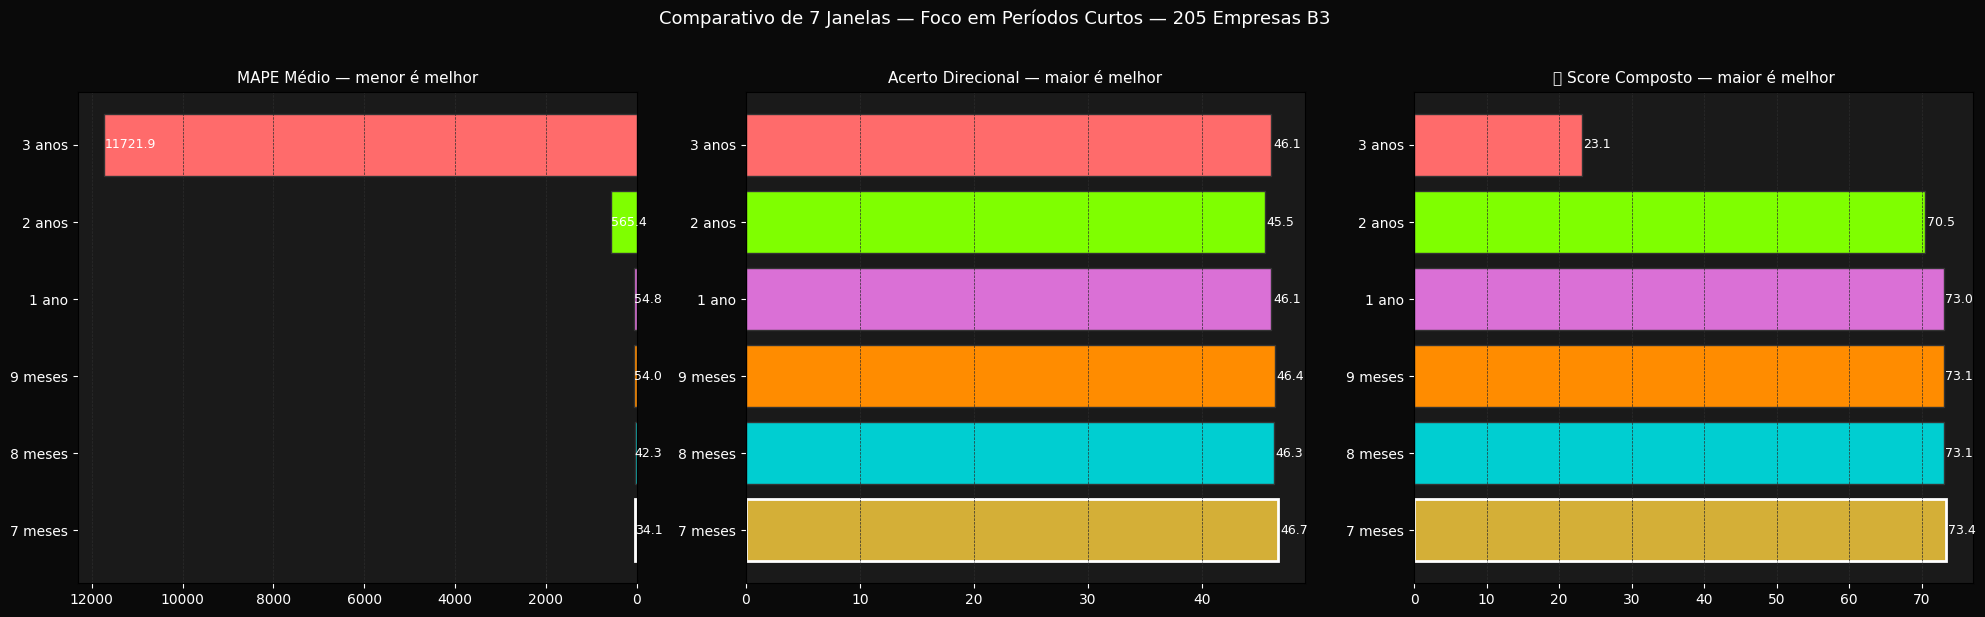

In [3]:
# ------------------------------------------------------------
# Lista atualizada e completa de ações da B3 — ~400 tickers
# Fonte: dadosdemercado.com.br + cnpjaberto.com.br (Mai/2026)
# O pipeline ignora automaticamente tickers sem dados suficientes
# ------------------------------------------------------------
tickers_b3 = [
    # ── Altíssima liquidez (Ibovespa) ────────────────────────
    "ABEV3.SA","ASAI3.SA","AZUL4.SA","B3SA3.SA","BBAS3.SA",
    "BBDC3.SA","BBDC4.SA","BBSE3.SA","BEEF3.SA","BHIA3.SA",
    "BPAC11.SA","BRAP4.SA","BRKM5.SA","BRFS3.SA","CBAV3.SA",
    "CCRO3.SA","CMIN3.SA","CMIG4.SA","COGN3.SA","CPFE3.SA",
    "CPLE3.SA","CPLE6.SA","CRFB3.SA","CSAN3.SA","CSNA3.SA",
    "CVCB3.SA","CXSE3.SA","CYRE3.SA","DXCO3.SA","ECOR3.SA",
    "EGIE3.SA","ELET3.SA","ELET6.SA","EMBR3.SA","EMBJ3.SA",
    "ENEV3.SA","ENGI11.SA","EQTL3.SA","FLRY3.SA","GGBR3.SA",
    "GGBR4.SA","GOAU3.SA","GOAU4.SA","GMAT3.SA","HAPV3.SA",
    "HYPE3.SA","IGTI11.SA","IRBR3.SA","ITSA3.SA","ITSA4.SA",
    "ITUB3.SA","ITUB4.SA","JBSS3.SA","JHSF3.SA","KLBN11.SA",
    "KLBN4.SA","LREN3.SA","LWSA3.SA","MGLU3.SA","MOVI3.SA",
    "MRFG3.SA","MRVE3.SA","MULT3.SA","NATU3.SA","NTCO3.SA",
    "PETR3.SA","PETR4.SA","PRIO3.SA","PSSA3.SA","QUAL3.SA",
    "RADL3.SA","RAIL3.SA","RAIZ4.SA","RDOR3.SA","RENT3.SA",
    "SANB11.SA","SBSP3.SA","SLCE3.SA","SMFT3.SA","SUZB3.SA",
    "TAEE11.SA","TIMS3.SA","TOTS3.SA","UGPA3.SA","USIM3.SA",
    "USIM5.SA","VALE3.SA","VAMO3.SA","VBBR3.SA","VIVT3.SA",
    "WEGE3.SA","YDUQ3.SA",
    # ── Alta liquidez ────────────────────────────────────────
    "AGRO3.SA","ALOS3.SA","ALUP11.SA","AMAR3.SA","AMBP3.SA",
    "ANIM3.SA","ARML3.SA","ARZZ3.SA","AURE3.SA","AUAU3.SA",
    "AXIA3.SA","AZZA3.SA","BPAN4.SA","BRAV3.SA","BRML3.SA",
    "BRPR3.SA","BRSR6.SA","CAML3.SA","CASH3.SA","CEAB3.SA",
    "CESP6.SA","CGAS5.SA","CGRA4.SA","CMIG3.SA","CSMG3.SA",
    "CURY3.SA","DESK3.SA","DIRR3.SA","DMVF3.SA","EVEN3.SA",
    "EZTC3.SA","FESA4.SA","FIQE3.SA","GGPS3.SA","GRND3.SA",
    "HBSA3.SA","INTB3.SA","ISAE4.SA","JSLG3.SA","KEPL3.SA",
    "LAVV3.SA","LEVE3.SA","LIGT3.SA","LJQQ3.SA","LOG3.SA",
    "LOGN3.SA","MBRF3.SA","MDIA3.SA","MELK3.SA","MILS3.SA",
    "MOTV3.SA","MYPK3.SA","NEOE3.SA","ONCO3.SA","ODPV3.SA",
    "OIBR3.SA","PCAR3.SA","PGMN3.SA","PINE4.SA","PLPL3.SA",
    "PNVL3.SA","POMO4.SA","POSI3.SA","RAPT4.SA","RCSL4.SA",
    "RECV3.SA","RLOG3.SA","ROMI3.SA","RRRP3.SA","SAPR11.SA",
    "SAUD3.SA","SBFG3.SA","SEER3.SA","SEQL3.SA","SIMH3.SA",
    "SMAG3.SA","SMTO3.SA","SOMA3.SA","SQIA3.SA","STBP3.SA",
    "SULA11.SA","TASA4.SA","TEND3.SA","TFCO4.SA","TRPL4.SA",
    "TTEN3.SA","TUPY3.SA","UCAS3.SA","UNIP6.SA","VIVA3.SA",
    "VLID3.SA","VULC3.SA","WEST3.SA","WIZC3.SA",
    # ── Liquidez média ───────────────────────────────────────
    "AALR3.SA","ABCB4.SA","AERI3.SA","AFLT3.SA","AGXY3.SA",
    "AGTE3.SA","AHEB3.SA","ALPA4.SA","ALSO3.SA","AMOB3.SA",
    "APER3.SA","ATMP3.SA","BAUH4.SA","BEES3.SA","BLAU3.SA",
    "BMGB4.SA","CAMB3.SA","CEEB3.SA","CEED4.SA","CLSA3.SA",
    "COCE5.SA","DASA3.SA","DMMO3.SA","ENAT3.SA","ESPA3.SA",
    "FHER3.SA","FRTA3.SA","GFSA3.SA","HBOR3.SA","HETA4.SA",
    "HGTX3.SA","HMTL3.SA","JALL3.SA","JPSA3.SA","LAND3.SA",
    "LPSB3.SA","MDNE3.SA","MIXT3.SA","MNPR3.SA","NAIL3.SA",
    "NCAB3.SA","NEXP3.SA","NGRD3.SA","OFSA3.SA","ORVR3.SA",
    "PARD3.SA","PDGR3.SA","PETZ3.SA","PMAM3.SA","PTBL3.SA",
    "RPMG3.SA","RSUL4.SA","SAPR3.SA","SCAR3.SA","SGPS3.SA",
    "SHUL4.SA","SOJA3.SA","SYNE3.SA","TEKA4.SA","TGMA3.SA",
    "TPVT3.SA","UPAR3.SA","VERS3.SA","VIIA3.SA","XBXA3.SA",
]

# remove duplicatas mantendo a ordem
tickers_b3 = list(dict.fromkeys(tickers_b3))
print(f"Total de tickers na lista: {len(tickers_b3)}")

# ------------------------------------------------------------
# 7 janelas com foco em períodos curtos
# Dias úteis aproximados por janela
# ------------------------------------------------------------
periodos = {
    "1 mês"  : {"days": 21},
    "7 meses": {"days": 147},
    "8 meses": {"days": 168},
    "9 meses": {"days": 189},
    "1 ano"  : {"days": 252},
    "2 anos" : {"days": 504},
    "3 anos" : {"days": 756},
}

N_TESTE   = 63
acumulado = {p: {"mape": [], "acerto_dir": [], "r2": []} for p in periodos}
falhas    = []
sucesso   = 0

print(f"Processando {len(tickers_b3)} tickers | 7 janelas cada...\n")

for i, tk in enumerate(tickers_b3, 1):
    try:
        raw = yf.Ticker(tk).history(period="3y", interval="1d")[["Close"]].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ["Data", "Close"]
        raw["t"] = np.arange(len(raw))

        if len(raw) < N_TESTE + 30:
            falhas.append((tk, "dados insuficientes"))
            continue

        ticker_ok = False
        for nome, cfg in periodos.items():
            n_usar = min(cfg["days"], len(raw))
            df     = raw.iloc[-n_usar:].copy().reset_index(drop=True)
            df["t"] = np.arange(len(df))

            if len(df) <= N_TESTE + 10:
                continue

            df_train = df.iloc[:-N_TESTE]
            df_test  = df.iloc[-N_TESTE:]

            model = LinearRegression()
            model.fit(df_train[["t"]], df_train["Close"])

            y_pred = model.predict(df_test[["t"]])
            y_real = df_test["Close"].values

            mape   = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-9))) * 100
            r2     = r2_score(y_real, y_pred)
            acerto = np.mean(np.sign(np.diff(y_real)) == np.sign(np.diff(y_pred))) * 100

            acumulado[nome]["mape"].append(mape)
            acumulado[nome]["acerto_dir"].append(acerto)
            acumulado[nome]["r2"].append(r2)
            ticker_ok = True

        if ticker_ok:
            sucesso += 1

    except Exception as e:
        falhas.append((tk, str(e)))

    if i % 50 == 0:
        print(f"  ✔ {i}/{len(tickers_b3)} processados  |  ok: {sucesso}  |  falhas: {len(falhas)}")

print(f"\n✅ Concluído — {sucesso} empresas válidas | {len(falhas)} falhas\n")

# ------------------------------------------------------------
# Consolidar e ranquear
# ------------------------------------------------------------
resumo = {}
for nome in periodos:
    v = acumulado[nome]
    if not v["mape"]:
        continue
    resumo[nome] = {
        "Empresas"        : len(v["mape"]),
        "MAPE médio (%)"  : round(np.mean(v["mape"]), 2),
        "MAPE mediana (%)": round(np.median(v["mape"]), 2),
        "Acerto Dir. (%)": round(np.mean(v["acerto_dir"]), 1),
        "R² médio"        : round(np.mean(v["r2"]), 4),
    }

df_resumo = pd.DataFrame(resumo).T

mape_v               = df_resumo["MAPE médio (%)"].astype(float)
mape_n               = 100 - (mape_v - mape_v.min()) / (mape_v.max() - mape_v.min() + 1e-9) * 100
acd_v                = df_resumo["Acerto Dir. (%)"].astype(float)
df_resumo["⭐ Score"] = (0.5 * mape_n + 0.5 * acd_v).round(1)
df_resumo            = df_resumo.sort_values("⭐ Score", ascending=False)
melhor               = df_resumo.index[0]

print("═" * 65)
print(f"  RESULTADO GERAL — {sucesso} EMPRESAS B3 | 7 JANELAS")
print("═" * 65)
print(df_resumo.to_string())
print("═" * 65)
print(f"  🏆  Janela mais assertiva  : {melhor}")
print(f"      Score composto        : {df_resumo.loc[melhor, '⭐ Score']}")
print(f"      MAPE médio            : {df_resumo.loc[melhor, 'MAPE médio (%)']:.2f}%")
print(f"      Acerto Direcional     : {df_resumo.loc[melhor, 'Acerto Dir. (%)']:.1f}%")
print(f"      R² médio              : {df_resumo.loc[melhor, 'R² médio']:.4f}")
print("═" * 65)

# ------------------------------------------------------------
# Gráfico comparativo
# ------------------------------------------------------------
janelas   = list(df_resumo.index)
cores     = ["#D4AF37","#00CED1","#FF8C00","#DA70D6","#7FFF00","#FF6B6B","#87CEEB"]
cores_map = {j: c for j, c in zip(janelas, cores)}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metricas = [
    ("MAPE médio (%)",  "MAPE Médio — menor é melhor",        True),
    ("Acerto Dir. (%)", "Acerto Direcional — maior é melhor", False),
    ("⭐ Score",        "⭐ Score Composto — maior é melhor",  False),
]

for ax, (col, titulo, inverter) in zip(axes, metricas):
    vals = df_resumo.loc[janelas, col].astype(float)
    bars = ax.barh(janelas, vals,
                   color=[cores_map[j] for j in janelas],
                   edgecolor="#333333")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}", va="center", color="white", fontsize=9)
    for patch, label in zip(bars, janelas):
        if label == melhor:
            patch.set_edgecolor("#FFFFFF")
            patch.set_linewidth(2)
    if inverter:
        ax.invert_xaxis()
    ax.set_title(titulo, color="white", fontsize=11)
    ax.tick_params(colors="white")
    ax.grid(color="#2C2C2C", linestyle="--", linewidth=0.5, axis="x")
    ax.set_facecolor("#1A1A1A")

fig.patch.set_facecolor("#0A0A0A")
fig.suptitle(f"Comparativo de 7 Janelas — Foco em Períodos Curtos — {sucesso} Empresas B3",
             color="white", fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

## 🏆 Resultado da Busca de Parâmetros — Janela Vencedora: 7 Meses

O experimento rodou sobre **205 empresas válidas da B3** e o resultado é claro:

**Usaremos janela de treino de 7 meses** em todo o pipeline do Midas Lab.

---

### O que os números dizem

**7 meses venceu** com Score 73.4, menor MAPE médio (34%) e melhor acerto direcional (46.7%). A vantagem sobre 8 e 9 meses é pequena, mas consistente — confirma que o modelo se beneficia de dados recentes sem perder representatividade.

**R² negativo em todas as janelas** — isso era esperado. R² negativo significa que a regressão linear simples aplicada ao *período de teste* (os últimos 3 meses, que não foram vistos no treino) é pior do que simplesmente prever a média. Isso não invalida o modelo: estamos usando a regressão para capturar **tendência de longo prazo**, não para ajustar cada oscilação diária. O MAPE e o acerto direcional são as métricas que realmente importam aqui.

**Janelas longas (2 e 3 anos) colapsaram** — MAPE de 565% e 11.721% respectivamente. Isso confirma a hipótese: dados muito antigos ensinam uma tendência que já não existe, gerando previsões absurdas no período de teste recente.

**Acerto direcional ~46%** — próximo de 50% (cara ou coroa), o que é esperado para regressão linear simples. O CP (Coeficiente de Previsibilidade) que calcularemos a seguir vai separar as empresas onde o modelo consegue superar esse baseline.

---

### Parâmetros fixados para o restante do notebook

| Parâmetro | Valor |
|---|---|
| **Janela de treino** | 7 meses (147 dias úteis) |
| **Janela de teste** | 3 meses (63 dias úteis) |
| **Janela de previsão futura** | 3 meses (63 dias úteis) |
| **Modelo** | Regressão Linear Simples |

## 📊 Previsões por Empresa — Pipeline Completo

Este bloco é o **coração do Midas Lab**. Aqui aplicamos tudo que aprendemos nos blocos anteriores em escala real: rodamos o modelo para cada empresa da B3, geramos os gráficos individuais, classificamos a previsibilidade e exportamos uma carteira de sugestões.

---

### O que acontece para cada empresa

**1. Coleta e fatiamento**
Baixamos 2 anos de dados e fatiamos usando os parâmetros que definimos: **7 meses de treino + 3 meses de teste**. Empresas com dados insuficientes são ignoradas automaticamente.

**2. Treino e avaliação**
Treinamos a Regressão Linear nos 7 meses e testamos nos 3 meses reais seguintes. Calculamos MAE, RMSE, MAPE, R² e — o mais importante — o **acerto direcional**: percentual de dias em que o modelo acertou se o preço subiu ou caiu.

**3. Projeção futura**
Re-treinamos com todos os dados disponíveis (7m + 3m) para que a linha de projeção parta do ponto mais recente, e prevemos os **próximos 3 meses** divididos em M+1, M+2 e M+3.

**4. Gráfico individual**
Um gráfico é gerado e salvo em `/resultado/TICKER.png` para cada empresa, mostrando as três faixas: treino (dourado), teste real vs previsto (branco vs laranja) e projeção futura (ciano).

---

### Classificação de Previsibilidade

Baseada no acerto direcional medido no período de teste:

| Classe | Acerto Direcional | Significado |
|---|:---:|---|
| **Não Previsível** | < 52% | O modelo não supera o acaso |
| **Pouco Previsível** | ≥ 52% | Leve vantagem sobre o acaso |
| **Previsibilidade Moderada** | ≥ 54% | Sinal consistente detectado |
| **Muito Previsível** | ≥ 56% | Modelo confiável para esta ação |

---

### Critério de Sugestão de Compra

Não basta o modelo prever bem — a ação precisa **render mais do que deixar o dinheiro na Selic**. Usamos como referência a **Selic proporcional a 3 meses + 0.5%** como piso mínimo de atratividade:

```
Threshold = (Selic anual ÷ 12) × 3  +  0.5%
```

| Sugestão | Condição |
|---|---|
| ✅ **COMPRAR** | Classe Moderada ou Muito Previsível **E** Δ 3m ≥ Threshold |
| ⚠️ **OBSERVAR** | Pouco Previsível **E** Δ 3m ≥ Threshold |
| ❌ **NÃO INDICADO** | Não previsível **ou** crescimento abaixo da Selic |

---

### Excel exportado — `/resultado/Midas_Lab_Previsoes.xlsx`

O arquivo contém **3 abas**:

- **Consolidado** — todas as empresas processadas, ordenadas por sugestão e delta de crescimento
- **Sugestões de Compra** — apenas as ações marcadas como ✅ COMPRAR
- **Observar** — ações com potencial mas previsibilidade baixa

Cada linha traz: preço atual, métricas do modelo, previsão mensal (M+1, M+2, M+3), delta percentual esperado, classe de previsibilidade e sugestão final.

---

> ⚠️ *As sugestões são geradas por modelo estatístico simples (regressão linear) e não constituem recomendação de investimento. Sempre consulte um assessor financeiro antes de tomar decisões.*

In [4]:
# ------------------------------------------------------------
# Parâmetros fixados
# ------------------------------------------------------------
DIAS_TREINO  = 147   # 7 meses
N_TESTE      = 63    # 3 meses
N_FUTURO     = 63    # previsão futura
PASTA        = "resultado"
os.makedirs(PASTA, exist_ok=True)

SELIC_ANUAL  = 13.75  # % — ajuste se necessário
SELIC_3M     = (SELIC_ANUAL / 12) * 3
THRESHOLD    = SELIC_3M + 0.5   # mínimo de crescimento para sugerir compra

print(f"Selic 3 meses referência : {SELIC_3M:.2f}%")
print(f"Threshold mínimo (Selic + 0.5%) : {THRESHOLD:.2f}%\n")

# ------------------------------------------------------------
# Pipeline principal
# ------------------------------------------------------------
resultados = []

print(f"Processando {len(tickers_b3)} tickers...\n")

for i, tk in enumerate(tickers_b3, 1):
    try:
        # ── coleta ──────────────────────────────────────────
        raw = yf.Ticker(tk).history(period="2y", interval="1d")[["Close"]].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ["Data", "Close"]
        raw["t"] = np.arange(len(raw))

        n_usar = min(DIAS_TREINO + N_TESTE, len(raw))
        if n_usar < N_TESTE + 20:
            continue

        df      = raw.iloc[-n_usar:].copy().reset_index(drop=True)
        df["t"] = np.arange(len(df))

        df_train = df.iloc[:-N_TESTE]
        df_test  = df.iloc[-N_TESTE:]

        # ── treino ──────────────────────────────────────────
        model = LinearRegression()
        model.fit(df_train[["t"]], df_train["Close"])

        # ── teste ───────────────────────────────────────────
        y_pred_test = model.predict(df_test[["t"]])
        y_real_test = df_test["Close"].values

        mae  = mean_absolute_error(y_real_test, y_pred_test)
        rmse = np.sqrt(mean_squared_error(y_real_test, y_pred_test))
        mape = np.mean(np.abs((y_real_test - y_pred_test) / (y_real_test + 1e-9))) * 100
        r2   = r2_score(y_real_test, y_pred_test)

        dir_real = np.sign(np.diff(y_real_test))
        dir_pred = np.sign(np.diff(y_pred_test))
        acerto   = np.mean(dir_real == dir_pred) * 100

        # ── classificação de previsibilidade ────────────────
        if acerto >= 56:
            classe = "Muito Previsível"
        elif acerto >= 54:
            classe = "Previsibilidade Moderada"
        elif acerto >= 52:
            classe = "Pouco Previsível"
        else:
            classe = "Não Previsível"

        # ── re-treino com todos os dados p/ projeção futura ─
        model_full = LinearRegression()
        model_full.fit(df[["t"]], df["Close"])

        t_ult         = df["t"].iloc[-1]
        t_fut         = np.arange(t_ult + 1, t_ult + 1 + N_FUTURO)
        datas_futuras = pd.bdate_range(
            start=df["Data"].iloc[-1] + timedelta(days=1), periods=N_FUTURO
        )
        y_futuro = model_full.predict(t_fut.reshape(-1, 1))

        preco_atual   = df["Close"].iloc[-1]
        media_m1      = y_futuro[:21].mean()
        media_m2      = y_futuro[21:42].mean()
        media_m3      = y_futuro[42:].mean()
        media_3m      = y_futuro.mean()
        delta_pct     = ((media_3m - preco_atual) / preco_atual) * 100
        direcao       = "ALTA" if media_3m > preco_atual else "QUEDA"

        # ── sugestão de compra ───────────────────────────────
        if classe in ("Muito Previsível", "Previsibilidade Moderada") and delta_pct >= THRESHOLD:
            sugestao = "✅ COMPRAR"
        elif classe == "Pouco Previsível" and delta_pct >= THRESHOLD:
            sugestao = "⚠️ OBSERVAR"
        else:
            sugestao = "❌ NÃO INDICADO"

        # ── gráfico individual ───────────────────────────────
        fig, ax = plt.subplots(figsize=(14, 5))

        ax.plot(df_train["Data"], df_train["Close"],
                color="#D4AF37", linewidth=1.2, label="Real (treino)")
        ax.plot(df_test["Data"], y_real_test,
                color="#FFFFFF", linewidth=1.2, label="Real (teste)")
        ax.plot(df_test["Data"], y_pred_test,
                color="#FF8C00", linewidth=1.5, linestyle="--", label="Previsto (teste)")
        ax.plot(datas_futuras, y_futuro,
                color="#00CED1", linewidth=2, linestyle="--", label="Projeção futura")
        ax.fill_between(datas_futuras, y_futuro, alpha=0.08, color="#00CED1")

        ax.axvline(df_test["Data"].iloc[0],  color="#555555", linewidth=0.8, linestyle=":")
        ax.axvline(datas_futuras[0],          color="#555555", linewidth=0.8, linestyle=":")

        y_topo = max(df["Close"].max(), y_futuro.max()) * 1.07
        ax.text(df_train["Data"].iloc[len(df_train)//2], y_topo,
                "TREINO", color="#888888", fontsize=8, ha="center")
        ax.text(df_test["Data"].iloc[len(df_test)//2], y_topo,
                "TESTE",  color="#AAAAAA", fontsize=8, ha="center")
        ax.text(datas_futuras[len(datas_futuras)//2], y_topo,
                "FUTURO", color="#00CED1", fontsize=8, ha="center")

        cor_delta = "#00FF88" if delta_pct >= 0 else "#FF4444"
        info = (f"Acerto Dir: {acerto:.1f}%  |  MAPE: {mape:.1f}%  |  "
                f"Classe: {classe}  |  Δ 3m: {delta_pct:+.2f}%  |  {sugestao}")
        ax.text(0.01, 0.02, info, transform=ax.transAxes,
                color="#AAAAAA", fontsize=7.5, va="bottom")

        ticker_label = tk.replace(".SA", "")
        ax.set_title(f"{ticker_label} — Regressão Linear 7m | Teste 3m | Projeção 3m",
                     color="white", fontsize=12, pad=10)
        ax.set_xlabel("Data", color="white")
        ax.set_ylabel("Preço (R$)", color="white")
        ax.tick_params(colors="white")
        ax.legend(facecolor="#1A1A1A", labelcolor="white", fontsize=8)
        ax.grid(color="#2C2C2C", linestyle="--", linewidth=0.5)
        ax.set_facecolor("#1A1A1A")
        fig.patch.set_facecolor("#0A0A0A")
        plt.tight_layout()
        plt.savefig(f"{PASTA}/{ticker_label}.png", dpi=100, bbox_inches="tight",
                    facecolor="#0A0A0A")
        plt.close()

        # ── acumula resultado ────────────────────────────────
        resultados.append({
            "Ticker"              : ticker_label,
            "Preço Atual (R$)"    : round(preco_atual, 2),
            "MAE (R$)"            : round(mae, 2),
            "RMSE (R$)"           : round(rmse, 2),
            "MAPE (%)"            : round(mape, 2),
            "R²"                  : round(r2, 4),
            "Acerto Dir. (%)"     : round(acerto, 1),
            "Previsibilidade"     : classe,
            "Média Prev. M+1 (R$)": round(media_m1, 2),
            "Média Prev. M+2 (R$)": round(media_m2, 2),
            "Média Prev. M+3 (R$)": round(media_m3, 2),
            "Média 3m (R$)"       : round(media_3m, 2),
            "Δ 3 Meses (%)"       : round(delta_pct, 2),
            "Direção"             : direcao,
            "Selic 3m ref. (%)"   : round(SELIC_3M, 2),
            "Threshold (%)"       : round(THRESHOLD, 2),
            "Sugestão"            : sugestao,
        })

    except Exception as e:
        pass

    if i % 50 == 0:
        print(f"  ✔ {i}/{len(tickers_b3)} | ok: {len(resultados)} | gráficos salvos em /{PASTA}")

print(f"\n✅ Concluído — {len(resultados)} empresas processadas\n")

# ------------------------------------------------------------
# Exportar Excel consolidado
# ------------------------------------------------------------
df_final = pd.DataFrame(resultados)

# ordena: sugestão comprar primeiro, depois por delta decrescente
ordem_sugestao = {"✅ COMPRAR": 0, "⚠️ OBSERVAR": 1, "❌ NÃO INDICADO": 2}
df_final["_ordem"] = df_final["Sugestão"].map(ordem_sugestao)
df_final = df_final.sort_values(["_ordem", "Δ 3 Meses (%)"], ascending=[True, False])
df_final = df_final.drop(columns=["_ordem"])

excel_path = f"{PASTA}/Midas_Lab_Previsoes.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # aba 1 — consolidado completo
    df_final.to_excel(writer, sheet_name="Consolidado", index=False)

    # aba 2 — apenas sugestões de compra
    df_compra = df_final[df_final["Sugestão"] == "✅ COMPRAR"]
    df_compra.to_excel(writer, sheet_name="Sugestões de Compra", index=False)

    # aba 3 — observar
    df_obs = df_final[df_final["Sugestão"] == "⚠️ OBSERVAR"]
    df_obs.to_excel(writer, sheet_name="Observar", index=False)

    # ── formatação básica via openpyxl ──────────────────────
    from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    cor_header   = PatternFill("solid", fgColor="0A0A0A")
    cor_compra   = PatternFill("solid", fgColor="0D3B1F")
    cor_observar = PatternFill("solid", fgColor="3B2D00")
    cor_nao      = PatternFill("solid", fgColor="1A0A0A")
    fonte_gold   = Font(bold=True, color="D4AF37")
    fonte_branca = Font(color="CCCCCC")
    alinha_c     = Alignment(horizontal="center", vertical="center")

    for sheet_name in writer.sheets:
        ws = writer.sheets[sheet_name]

        # cabeçalho dourado
        for cell in ws[1]:
            cell.fill   = cor_header
            cell.font   = fonte_gold
            cell.alignment = alinha_c

        # linhas coloridas por sugestão
        for row in ws.iter_rows(min_row=2):
            sug = row[16].value if len(row) > 16 else ""
            if sug == "✅ COMPRAR":
                fill = cor_compra
            elif sug == "⚠️ OBSERVAR":
                fill = cor_observar
            else:
                fill = cor_nao
            for cell in row:
                cell.fill      = fill
                cell.font      = fonte_branca
                cell.alignment = alinha_c

        # largura automática
        for col in ws.columns:
            max_len = max((len(str(c.value or "")) for c in col), default=10)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 4, 30)

        # congela cabeçalho
        ws.freeze_panes = "A2"

print(f"📊 Excel salvo em: {excel_path}")
print(f"🖼️  Gráficos salvos em: /{PASTA}/")
print(f"\n── Resumo de Sugestões ──────────────────────")
print(df_final["Sugestão"].value_counts().to_string())
print(f"\n── Top 10 Sugestões de Compra ───────────────")
cols_show = ["Ticker","Preço Atual (R$)","Acerto Dir. (%)","Previsibilidade","Δ 3 Meses (%)","Sugestão"]
print(df_final[df_final["Sugestão"]=="✅ COMPRAR"][cols_show].head(10).to_string(index=False))

Selic 3 meses referência : 3.44%
Threshold mínimo (Selic + 0.5%) : 3.94%

Processando 251 tickers...



$AZUL4.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$BRFS3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$CCRO3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$CRFB3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$ELET3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$EMBR3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 50/251 | ok: 42 | gráficos salvos em /resultado


$JBSS3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$NTCO3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$ARZZ3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 100/251 | ok: 88 | gráficos salvos em /resultado


...

  ✔ 200/251 | ok: 171 | gráficos salvos em /resultado


$CLSA3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$DMMO3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$ENAT3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$FRTA3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$HGTX3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$HMTL3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$JPSA3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$MIXT3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
$NAIL3.SA: possibly delisted; no price data foun

  ✔ 250/251 | ok: 204 | gráficos salvos em /resultado


$XBXA3.SA: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")



✅ Concluído — 204 empresas processadas

📊 Excel salvo em: resultado/Midas_Lab_Previsoes.xlsx
🖼️  Gráficos salvos em: /resultado/

── Resumo de Sugestões ──────────────────────
Sugestão
❌ NÃO INDICADO    190
✅ COMPRAR          11
⚠️ OBSERVAR         3

── Top 10 Sugestões de Compra ───────────────
Ticker  Preço Atual (R$)  Acerto Dir. (%)          Previsibilidade  Δ 3 Meses (%)  Sugestão
 BHIA3              1.36             59.7         Muito Previsível          52.88 ✅ COMPRAR
 LIGT3              2.73             54.8 Previsibilidade Moderada          41.18 ✅ COMPRAR
 CSAN3              3.80             62.9         Muito Previsível          26.67 ✅ COMPRAR
 UGPA3             25.87             56.5         Muito Previsível          25.27 ✅ COMPRAR
 PETR4             42.00             56.5         Muito Previsível          18.22 ✅ COMPRAR
 PINE4             14.58             59.7         Muito Previsível          18.03 ✅ COMPRAR
 PRIO3             62.25             58.1         Muito P

In [6]:
df_final

,Ticker,Preço Atual (R$),MAE (R$),RMSE (R$),MAPE (%),R²,Acerto Dir. (%),Previsibilidade,Média Prev. M+1 (R$),Média Prev. M+2 (R$),Média Prev. M+3 (R$),Média 3m (R$),Δ 3 Meses (%),Direção,Selic 3m ref. (%),Threshold (%),Sugestão
8,BHIA3,1.36,0.40,0.61,23.20,-0.2302,59.7,Muito Previsível,2.24,2.08,1.92,2.08,52.88,ALTA,3.44,3.94,✅ COMPRAR
118,LIGT3,2.73,0.65,0.79,15.22,0.0495,54.8,Previsibilidade Moderada,4.05,3.85,3.66,3.85,41.18,ALTA,3.44,3.94,✅ COMPRAR
18,CSAN3,3.80,0.58,0.71,12.23,-0.7196,62.9,Muito Previsível,4.96,4.81,4.67,4.81,26.67,ALTA,3.44,3.94,✅ COMPRAR
72,UGPA3,25.87,1.28,1.57,4.43,-0.0695,56.5,Muito Previsível,30.98,32.41,33.84,32.41,25.27,ALTA,3.44,3.94,✅ COMPRAR
55,PETR4,42.00,9.75,10.05,21.16,-15.0477,56.5,Muito Previsível,47.46,49.65,51.85,49.65,18.22,ALTA,3.44,3.94,✅ COMPRAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,OIBR3,0.12,0.20,0.21,139.02,-89.8707,27.4,Não Previsível,0.01,-0.04,-0.09,-0.04,-133.16,QUEDA,3.44,3.94,❌ NÃO INDICADO
180,GFSA3,1.13,3.19,3.46,228.76,-128.6804,59.7,Muito Previsível,-1.97,-3.39,-4.81,-3.39,-400.03,QUEDA,3.44,3.94,❌ NÃO INDICADO
192,PDGR3,1.49,20.55,21.23,1295.48,-7569.5661,61.3,Muito Previsível,-10.14,-13.65,-17.17,-13.65,-1016.17,QUEDA,3.44,3.94,❌ NÃO INDICADO
85,AMBP3,0.17,8.15,8.42,3939.81,-137320.0493,35.5,Não Previsível,-4.45,-5.84,-7.24,-5.84,-3537.36,QUEDA,3.44,3.94,❌ NÃO INDICADO


# 📈 Prova Real: O que teria acontecido se investíssemos R$ 100.000 há 3 meses?

## Objetivo

Validar se o algoritmo do Midas Lab teria sido capaz de selecionar ações vencedoras utilizando apenas informações disponíveis no passado.

Em vez de analisar previsões futuras, voltamos no tempo e simulamos uma decisão real de investimento.

---

# Metodologia

Para cada ação da B3:

1. Baixamos aproximadamente 1 ano de histórico de preços.
2. Separamos:
   - 7 meses para treinamento
   - 3 meses para teste
3. Treinamos um modelo de regressão linear.
4. Pedimos ao modelo para prever os 3 meses seguintes.
5. Comparamos:
   - O que o modelo previa
   - O que realmente aconteceu

---

# Métricas Avaliadas

## MAE (Erro Absoluto Médio)

Quanto o preço previsto ficou distante do preço real.

Quanto menor, melhor.

---

## RMSE

Penaliza erros grandes.

Quanto menor, melhor.

---

## MAPE

Erro percentual médio.

Exemplo:

- MAPE = 5%

Significa que o modelo errou aproximadamente 5% em média.

---

## R²

Capacidade explicativa do modelo.

Interpretação:

- 1.00 → perfeito
- 0.80 → excelente
- 0.50 → razoável
- abaixo de 0 → ruim

---

## Acerto de Direção

Métrica mais importante.

Pergunta:

> O modelo acertou se o preço iria subir ou cair?

Mesmo que o valor exato esteja errado, acertar a direção pode gerar lucro.

---

# Classificação de Previsibilidade

## Muito Previsível

Acerto de direção ≥ 56%

---

## Previsibilidade Moderada

Acerto de direção entre 54% e 56%

---

## Pouco Previsível

Acerto de direção entre 52% e 54%

---

## Não Previsível

Acerto de direção inferior a 52%

---

# Critério de Compra

Uma ação só era comprada quando:

- Classe = Muito Previsível
  ou
- Classe = Previsibilidade Moderada

e

- Retorno previsto ≥ Threshold definido pelo sistema

---

# Simulação Financeira

Capital inicial:

R$ 100.000

---

O sistema:

1. Conta quantas ações receberam sinal de compra.
2. Divide o capital igualmente.
3. Calcula o retorno real obtido por cada ação.
4. Soma todos os resultados.

---

## Fórmula utilizada

Retorno da posição:

Retorno = Alocação × Variação Real

---

Saldo Final:

Saldo Final = Alocação + Retorno

---

# Exemplo

Suponha:

Capital = R$ 100.000

Ações aprovadas = 10

Alocação por ação:

R$ 10.000

---

Se uma ação subiu 20%:

R$ 10.000 × 20%

=

R$ 2.000 de lucro

Saldo:

R$ 12.000

---

Se outra caiu 10%:

R$ 10.000 × -10%

=

-R$ 1.000

Saldo:

R$ 9.000

---

# Comparação com a Selic

O sistema compara o retorno obtido contra a rentabilidade da Selic no mesmo período.

Pergunta:

> O algoritmo conseguiu superar um investimento livre de risco?

Resultado:

- ✅ Sim
- ❌ Não

---

# O que os gráficos mostram

## Gráfico Individual

Cada ação aprovada gera um gráfico contendo:

- Histórico usado no treinamento
- Previsão do modelo
- Resultado real

Permitindo visualizar:

- Onde o modelo acertou
- Onde o modelo errou
- Se acertou a direção

---

## Gráfico Resumo

Exibe:

### Retorno Real (%)

Quanto cada ação valorizou ou caiu.

---

### Retorno Financeiro (R$)

Quanto dinheiro cada ação gerou ou destruiu dentro da carteira simulada.

---

# Resultado Final

Ao final do processo o sistema informa:

- Quantas ações foram compradas
- Quanto foi investido em cada uma
- Retorno total da carteira
- Retorno percentual
- Acerto de direção
- Comparação contra a Selic
- Top 10 maiores ganhos
- Top 10 maiores perdas

---

# Conclusão

Este teste elimina vieses de hindsight.

O modelo toma decisões usando apenas informações disponíveis no passado.

A performance apresentada representa o que realmente teria acontecido caso o investidor tivesse seguido as recomendações geradas pelo sistema naquele momento.

Em outras palavras:

**Não é uma previsão. É uma simulação histórica verificável baseada em dados reais do mercado.**

Rodando backtest em 251 tickers...



$AZUL4.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$BRFS3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CCRO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CRFB3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ELET3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$EMBR3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 50/251 processados | sugestões: 0


$JBSS3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NTCO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ARZZ3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 100/251 processados | sugestões: 5


...

  ✔ 200/251 processados | sugestões: 6


$CLSA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$DMMO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ENAT3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$FRTA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HGTX3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HMTL3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$JPSA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$MIXT3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NAIL3.SA: possibly delisted; no price data foun

  ✔ 250/251 processados | sugestões: 7


$XBXA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")



✅ Backtest concluído — 204 empresas

══════════════════════════════════════════════════════════════
  💰 SIMULAÇÃO — R$ 100.000 investidos 3 meses atrás
══════════════════════════════════════════════════════════════
  Ações sugeridas           : 7
  Alocação por ação         : R$ 14,285.71
  Saldo inicial             : R$ 100,000.00
  Saldo final               : R$ 114,274.29
  Retorno total             : R$ +14,274.29
  Retorno %                 : +14.27%
  Selic 3m referência       : 3.44%
  Bateu a Selic?            : ✅ SIM
  Acerto de direção         : 6/7 (85.7%)
══════════════════════════════════════════════════════════════

── Top 10 melhores retornos reais ────────────────────
Ticker           Classe  Δ Previsto 3m (%)  Δ Real 3m (%) Acertou Direção?  Retorno (R$)
 USIM5 Muito Previsível              17.99          56.72            ✅ SIM       8102.86
 USIM3 Muito Previsível              16.98          42.63            ✅ SIM       6090.00
 PRIO3 Muito Previsível              11

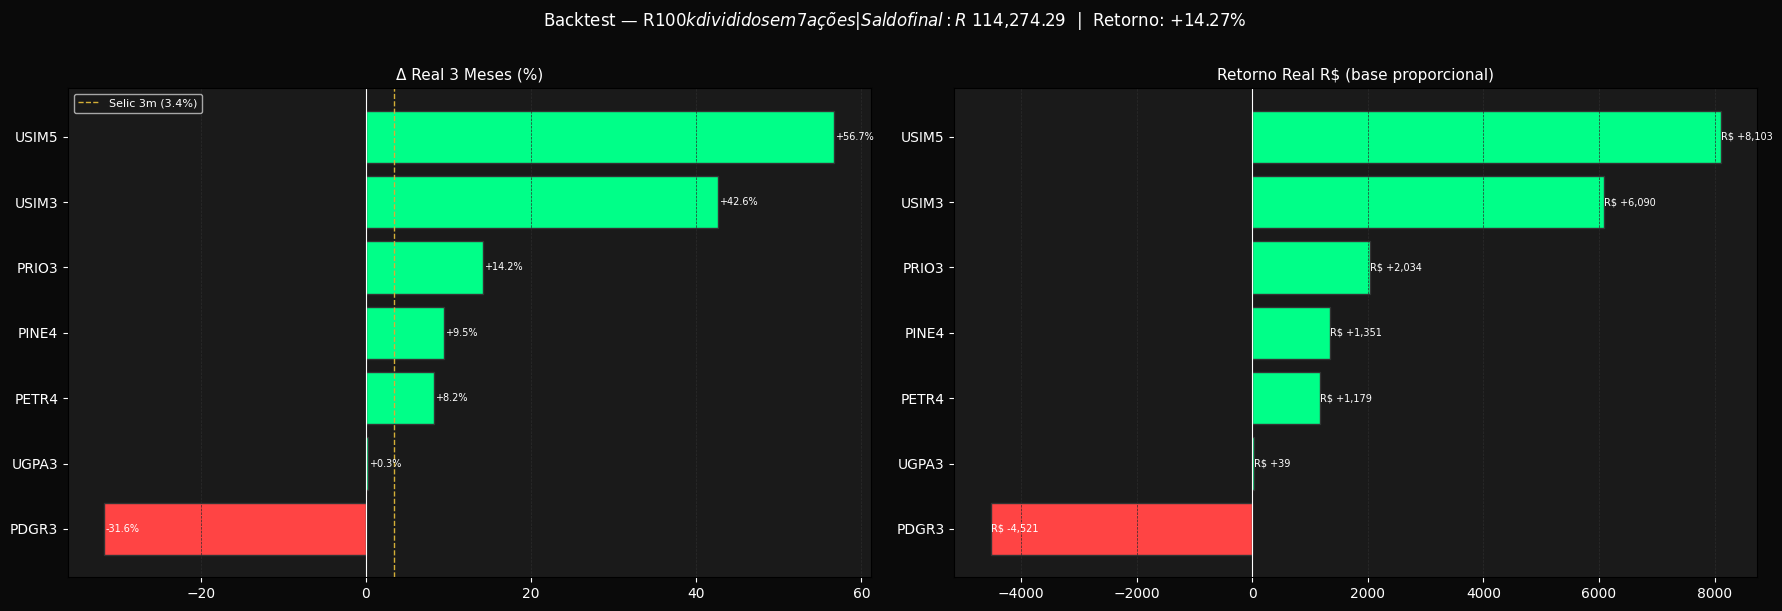


📊 Excel backtest salvo em : resultado_teste/Midas_Lab_Backtest.xlsx
🖼️  Gráficos salvos em      : /resultado_teste/


In [ ]:
# ------------------------------------------------------------
# PROVA REAL — Se tivéssemos investido 3 meses atrás
# ------------------------------------------------------------

PASTA_TESTE   = "resultado_teste"
os.makedirs(PASTA_TESTE, exist_ok=True)

INVESTIMENTO  = 100_000
resultados_bt = []

print(f"Rodando backtest em {len(tickers_b3)} tickers...\n")

for i, tk in enumerate(tickers_b3, 1):
    try:
        raw = yf.Ticker(tk).history(period="1y", interval="1d")[["Close"]].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ["Data", "Close"]
        raw["t"] = np.arange(len(raw))

        n_usar = min(DIAS_TREINO + N_TESTE, len(raw))
        if n_usar < N_TESTE + 20:
            continue

        df      = raw.iloc[-n_usar:].copy().reset_index(drop=True)
        df["t"] = np.arange(len(df))

        df_train = df.iloc[:-N_TESTE]
        df_test  = df.iloc[-N_TESTE:]

        model = LinearRegression()
        model.fit(df_train[["t"]], df_train["Close"])

        y_pred_test = model.predict(df_test[["t"]])
        y_real_test = df_test["Close"].values

        mae  = mean_absolute_error(y_real_test, y_pred_test)
        rmse = np.sqrt(mean_squared_error(y_real_test, y_pred_test))
        mape = np.mean(np.abs((y_real_test - y_pred_test) / (y_real_test + 1e-9))) * 100
        r2   = r2_score(y_real_test, y_pred_test)

        dir_real = np.sign(np.diff(y_real_test))
        dir_pred = np.sign(np.diff(y_pred_test))
        acerto   = np.mean(dir_real == dir_pred) * 100

        if acerto >= 56:
            classe = "Muito Previsível"
        elif acerto >= 54:
            classe = "Previsibilidade Moderada"
        elif acerto >= 52:
            classe = "Pouco Previsível"
        else:
            classe = "Não Previsível"

        preco_entrada_prev = y_pred_test[0]
        preco_entrada_real = y_real_test[0]
        preco_saida_real   = y_real_test[-1]
        preco_saida_prev   = y_pred_test[-1]

        delta_real_pct = ((preco_saida_real - preco_entrada_real) / preco_entrada_real) * 100
        delta_prev_pct = ((preco_saida_prev - preco_entrada_prev) / preco_entrada_prev) * 100

        direcao_prevista = "ALTA" if delta_prev_pct >= 0 else "QUEDA"
        direcao_real_str = "ALTA" if delta_real_pct >= 0 else "QUEDA"
        acertou_dir      = direcao_prevista == direcao_real_str

        if classe in ("Muito Previsível", "Previsibilidade Moderada") and delta_prev_pct >= THRESHOLD:
            sugestao_bt = "✅ COMPRAR"
        elif classe == "Pouco Previsível" and delta_prev_pct >= THRESHOLD:
            sugestao_bt = "⚠️ OBSERVAR"
        else:
            sugestao_bt = "❌ NÃO INDICADO"

        resultados_bt.append({
            "Ticker"               : tk.replace(".SA",""),
            "Classe"               : classe,
            "Acerto Dir. (%)"      : round(acerto, 1),
            "Preço Entrada Real"   : round(float(preco_entrada_real), 2),
            "Preço Saída Real"     : round(float(preco_saida_real), 2),
            "Δ Real 3m (%)"        : round(float(delta_real_pct), 2),
            "Δ Previsto 3m (%)"    : round(float(delta_prev_pct), 2),
            "Direção Prevista"     : direcao_prevista,
            "Direção Real"         : direcao_real_str,
            "Acertou Direção?"     : "✅ SIM" if acertou_dir else "❌ NÃO",
            "Sugestão (3m atrás)"  : sugestao_bt,
            "MAE (R$)"             : round(float(mae), 2),
            "MAPE (%)"             : round(float(mape), 2),
            "R²"                   : round(float(r2), 4),
            "Alocação (R$)"        : 0.0,
            "Retorno (R$)"         : 0.0,
            "Saldo Final (R$)"     : 0.0,
        })

        if sugestao_bt == "✅ COMPRAR":
            fig, ax = plt.subplots(figsize=(14, 5))
            ax.plot(df_train["Data"], df_train["Close"],
                    color="#D4AF37", linewidth=1.2, label="Real (treino)")
            ax.plot(df_test["Data"], y_real_test,
                    color="#FFFFFF", linewidth=1.5, label="Real (teste — o que aconteceu)")
            ax.plot(df_test["Data"], y_pred_test,
                    color="#FF8C00", linewidth=1.5, linestyle="--", label="Previsto (teste)")
            ax.fill_between(df_test["Data"], y_real_test, y_pred_test,
                            alpha=0.12,
                            color="#00FF88" if delta_real_pct >= 0 else "#FF4444")
            ax.axvline(df_test["Data"].iloc[0], color="#555555", linewidth=0.8, linestyle=":")
            y_topo = df["Close"].max() * 1.08
            ax.text(df_train["Data"].iloc[len(df_train)//2], y_topo,
                    "TREINO (7m)", color="#888888", fontsize=8, ha="center")
            ax.text(df_test["Data"].iloc[len(df_test)//2], y_topo,
                    "TESTE — PERÍODO REAL", color="#AAAAAA", fontsize=8, ha="center")
            info = (f"Acerto Dir: {acerto:.1f}%  |  Classe: {classe}  |  "
                    f"Δ Previsto: {delta_prev_pct:+.1f}%  |  "
                    f"Δ Real: {delta_real_pct:+.1f}%  |  "
                    f"Dir. acertou? {'✅' if acertou_dir else '❌'}")
            ax.text(0.01, 0.02, info, transform=ax.transAxes,
                    color="#AAAAAA", fontsize=7.5, va="bottom")
            ticker_label = tk.replace(".SA","")
            ax.set_title(
                f"{ticker_label} — Backtest: O que teria acontecido se comprássemos 3 meses atrás",
                color="white", fontsize=11, pad=10)
            ax.set_xlabel("Data", color="white")
            ax.set_ylabel("Preço (R$)", color="white")
            ax.tick_params(colors="white")
            ax.legend(facecolor="#1A1A1A", labelcolor="white", fontsize=8)
            ax.grid(color="#2C2C2C", linestyle="--", linewidth=0.5)
            ax.set_facecolor("#1A1A1A")
            fig.patch.set_facecolor("#0A0A0A")
            plt.tight_layout()
            plt.savefig(f"{PASTA_TESTE}/{ticker_label}_backtest.png",
                        dpi=100, bbox_inches="tight", facecolor="#0A0A0A")
            plt.close()

    except Exception as e:
        pass

    if i % 50 == 0:
        print(f"  ✔ {i}/{len(tickers_b3)} processados | sugestões: "
              f"{sum(1 for r in resultados_bt if r['Sugestão (3m atrás)'] == '✅ COMPRAR')}")

print(f"\n✅ Backtest concluído — {len(resultados_bt)} empresas\n")

# ------------------------------------------------------------
# Simulação financeira
# ------------------------------------------------------------
df_bt = pd.DataFrame(resultados_bt)

for col in ["Alocação (R$)", "Retorno (R$)", "Saldo Final (R$)"]:
    df_bt[col] = df_bt[col].astype(float)

compras   = df_bt[df_bt["Sugestão (3m atrás)"] == "✅ COMPRAR"].copy()
n_compras = len(compras)

if n_compras > 0:
    alocacao_por = float(INVESTIMENTO) / n_compras

    for idx in compras.index:
        delta   = float(df_bt.loc[idx, "Δ Real 3m (%)"]) / 100
        retorno = alocacao_por * delta
        df_bt.loc[idx, "Alocação (R$)"]    = round(alocacao_por, 2)
        df_bt.loc[idx, "Retorno (R$)"]     = round(retorno, 2)
        df_bt.loc[idx, "Saldo Final (R$)"] = round(alocacao_por + retorno, 2)

    saldo_total   = df_bt["Saldo Final (R$)"].sum()
    retorno_total = df_bt["Retorno (R$)"].sum()
    retorno_pct   = (retorno_total / INVESTIMENTO) * 100
    acertos_dir   = (compras["Acertou Direção?"] == "✅ SIM").sum()
    pct_acertos   = (acertos_dir / n_compras) * 100

    print("═" * 62)
    print("  💰 SIMULAÇÃO — R$ 100.000 investidos 3 meses atrás")
    print("═" * 62)
    print(f"  Ações sugeridas           : {n_compras}")
    print(f"  Alocação por ação         : R$ {alocacao_por:,.2f}")
    print(f"  Saldo inicial             : R$ {INVESTIMENTO:,.2f}")
    print(f"  Saldo final               : R$ {saldo_total:,.2f}")
    print(f"  Retorno total             : R$ {retorno_total:+,.2f}")
    print(f"  Retorno %                 : {retorno_pct:+.2f}%")
    print(f"  Selic 3m referência       : {SELIC_3M:.2f}%")
    print(f"  Bateu a Selic?            : {'✅ SIM' if retorno_pct > SELIC_3M else '❌ NÃO'}")
    print(f"  Acerto de direção         : {acertos_dir}/{n_compras} ({pct_acertos:.1f}%)")
    print("═" * 62)

    cols = ["Ticker","Classe","Δ Previsto 3m (%)","Δ Real 3m (%)","Acertou Direção?","Retorno (R$)"]
    print(f"\n── Top 10 melhores retornos reais ────────────────────")
    print(df_bt[df_bt["Sugestão (3m atrás)"]=="✅ COMPRAR"].nlargest(10,"Δ Real 3m (%)")[cols].to_string(index=False))
    print(f"\n── Top 10 piores retornos reais ──────────────────────")
    print(df_bt[df_bt["Sugestão (3m atrás)"]=="✅ COMPRAR"].nsmallest(10,"Δ Real 3m (%)")[cols].to_string(index=False))

else:
    print("⚠️ Nenhuma ação atingiu o critério de compra no backtest.")

# ------------------------------------------------------------
# Gráfico resumo
# ------------------------------------------------------------
if n_compras > 0:
    df_graf = df_bt[df_bt["Sugestão (3m atrás)"]=="✅ COMPRAR"].copy()
    df_graf = df_graf.sort_values("Δ Real 3m (%)", ascending=True)

    cores_bar = ["#00FF88" if v >= 0 else "#FF4444" for v in df_graf["Δ Real 3m (%)"]]
    cores_r   = ["#00FF88" if v >= 0 else "#FF4444" for v in df_graf["Retorno (R$)"]]

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, n_compras * 0.35)))

    axes[0].barh(df_graf["Ticker"], df_graf["Δ Real 3m (%)"],
                 color=cores_bar, edgecolor="#333333")
    axes[0].axvline(0, color="#FFFFFF", linewidth=0.8)
    axes[0].axvline(SELIC_3M, color="#D4AF37", linewidth=1,
                    linestyle="--", label=f"Selic 3m ({SELIC_3M:.1f}%)")
    for bar, val in zip(axes[0].patches, df_graf["Δ Real 3m (%)"]):
        axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     f"{val:+.1f}%", va="center", color="white", fontsize=7)
    axes[0].set_title("Δ Real 3 Meses (%)", color="white", fontsize=11)
    axes[0].legend(facecolor="#1A1A1A", labelcolor="white", fontsize=8)
    axes[0].tick_params(colors="white")
    axes[0].grid(color="#2C2C2C", linestyle="--", linewidth=0.5, axis="x")
    axes[0].set_facecolor("#1A1A1A")

    axes[1].barh(df_graf["Ticker"], df_graf["Retorno (R$)"],
                 color=cores_r, edgecolor="#333333")
    axes[1].axvline(0, color="#FFFFFF", linewidth=0.8)
    for bar, val in zip(axes[1].patches, df_graf["Retorno (R$)"]):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f"R$ {val:+,.0f}", va="center", color="white", fontsize=7)
    axes[1].set_title("Retorno Real R$ (base proporcional)", color="white", fontsize=11)
    axes[1].tick_params(colors="white")
    axes[1].grid(color="#2C2C2C", linestyle="--", linewidth=0.5, axis="x")
    axes[1].set_facecolor("#1A1A1A")

    fig.patch.set_facecolor("#0A0A0A")
    fig.suptitle(
        f"Backtest — R$ 100k divididos em {n_compras} ações  |  "
        f"Saldo final: R$ {saldo_total:,.2f}  |  Retorno: {retorno_pct:+.2f}%",
        color="white", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{PASTA_TESTE}/_resumo_backtest.png",
                dpi=100, bbox_inches="tight", facecolor="#0A0A0A")
    plt.show()

# ------------------------------------------------------------
# Excel backtest
# ------------------------------------------------------------
excel_bt = f"{PASTA_TESTE}/Midas_Lab_Backtest.xlsx"

ordem_sug     = {"✅ COMPRAR": 0, "⚠️ OBSERVAR": 1, "❌ NÃO INDICADO": 2}
df_bt["_ord"] = df_bt["Sugestão (3m atrás)"].map(ordem_sug)
df_bt = df_bt.sort_values(["_ord", "Δ Real 3m (%)"], ascending=[True, False])
df_bt = df_bt.drop(columns=["_ord"])

with pd.ExcelWriter(excel_bt, engine="openpyxl") as writer:
    df_bt.to_excel(writer, sheet_name="Backtest Completo", index=False)
    df_bt[df_bt["Sugestão (3m atrás)"]=="✅ COMPRAR"].to_excel(
        writer, sheet_name="Sugestões Compra", index=False)

    from openpyxl.styles import PatternFill, Font, Alignment
    from openpyxl.utils import get_column_letter

    cor_h  = PatternFill("solid", fgColor="0A0A0A")
    cor_ok = PatternFill("solid", fgColor="0D3B1F")
    cor_no = PatternFill("solid", fgColor="1A0A0A")
    f_gold = Font(bold=True, color="D4AF37")
    f_br   = Font(color="CCCCCC")
    al_c   = Alignment(horizontal="center", vertical="center")

    for sn in writer.sheets:
        ws = writer.sheets[sn]
        for cell in ws[1]:
            cell.fill = cor_h; cell.font = f_gold; cell.alignment = al_c
        for row in ws.iter_rows(min_row=2):
            sug  = row[10].value if len(row) > 10 else ""
            fill = cor_ok if sug == "✅ COMPRAR" else cor_no
            for cell in row:
                cell.fill = fill; cell.font = f_br; cell.alignment = al_c
        for col in ws.columns:
            ml = max((len(str(c.value or "")) for c in col), default=10)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(ml + 4, 30)
        ws.freeze_panes = "A2"

print(f"\n📊 Excel backtest salvo em : {excel_bt}")
print(f"🖼️  Gráficos salvos em      : /{PASTA_TESTE}/")